In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, top_k_accuracy_score,
                              classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import warnings, json, os, time, random
from pathlib import Path

# ── Safe SHAP import (won't crash if shap isn't installed) ───────────────
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('  ⚠ shap not installed — SHAP analysis will be skipped.')

warnings.filterwarnings('ignore')

  ⚠ shap not installed — SHAP analysis will be skipped.


In [2]:
# ── Reproducibility ──────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Running on: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Running on: cuda
GPU: NVIDIA A100-SXM4-40GB MIG 3g.20gb


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION 1 — MODEL ARCHITECTURE  (GRTT — sized smaller)
#
#  Corrected defaults (vs broken run):
#    ✦ d_token    : 256  →  128   (~1.7M → ~600K params on this dataset)
#    ✦ n_heads    : 8    →  4
#    ✦ token_drop : 0.10 →  0.05
# ═══════════════════════════════════════════════════════════════════════════════

class GEGLU(nn.Module):
    def __init__(self, d_model: int, d_ff: int):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff * 2)
        self.fc2 = nn.Linear(d_ff, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        a, b = self.fc1(x).chunk(2, dim=-1)
        return self.fc2(a * F.gelu(b))


class TransformerBlock(nn.Module):
    def __init__(self, d_model: int = 128, n_heads: int = 4,
                 d_ff: int = 256, dropout: float = 0.2):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads,
                                          dropout=dropout, batch_first=True)
        self.ln2  = nn.LayerNorm(d_model)
        self.ff   = GEGLU(d_model, d_ff)
        self.drop = nn.Dropout(dropout)

        # Learnable scalar gates — Gated Residuals
        self.attn_gate = nn.Parameter(torch.zeros(1))
        self.ff_gate   = nn.Parameter(torch.zeros(1))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.ln1(x)
        attn_out, _ = self.attn(h, h, h, need_weights=False)
        x = x + torch.sigmoid(self.attn_gate) * self.drop(attn_out)

        h      = self.ln2(x)
        ff_out = self.ff(h)
        x = x + torch.sigmoid(self.ff_gate) * self.drop(ff_out)
        return x


class GRTT(nn.Module):
    def __init__(self,
                 num_binary:     int,
                 num_continuous: int,
                 cat_dims:       list,
                 num_classes:    int,
                 d_token:  int   = 128,        # ✦ 256 → 128
                 depth:    int   = 2,
                 n_heads:  int   = 4,          # ✦ 8 → 4
                 d_ff:     int   = None,
                 dropout:  float = 0.2,
                 token_drop: float = 0.05):    # ✦ 0.10 → 0.05
        super().__init__()

        if d_ff is None:
            d_ff = d_token * 2

        self.num_cat        = len(cat_dims)
        self.num_continuous = num_continuous
        self.token_drop     = token_drop

        # Categorical embeddings
        self.cat_embeds = nn.ModuleList(
            [nn.Embedding(card, emb) for card, emb in cat_dims])
        self.cat_proj   = nn.ModuleList(
            [nn.Linear(emb, d_token) for _, emb in cat_dims])

        # Continuous — per-feature projection + learnable scale
        self.cont_proj  = nn.ModuleList(
            [nn.Linear(1, d_token) for _ in range(num_continuous)])
        self.cont_scale = nn.ParameterList(
            [nn.Parameter(torch.ones(d_token)) for _ in range(num_continuous)])

        # Binary — all binary cols → single token (gated linear)
        self.bin_linear = nn.Linear(num_binary, d_token)
        self.bin_gate   = nn.Parameter(torch.zeros(1))

        # Positional encoding
        self.max_tokens = (1
                           + self.num_cat
                           + num_continuous
                           + (1 if num_binary > 0 else 0))

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_token))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.max_tokens, d_token))

        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model=d_token, n_heads=n_heads,
                             d_ff=d_ff, dropout=dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(d_token)

        # Projection head (for SupCon)
        self.proj_head = nn.Sequential(
            nn.Linear(d_token, d_token * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(d_token * 2, d_token),
            nn.ReLU(inplace=True),
            nn.Linear(d_token, 128),
        )

        # Classification head
        self.head = nn.Linear(d_token, num_classes)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.trunc_normal_(m.weight, std=0.02)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, xb: torch.Tensor,
                       xc: torch.Tensor,
                       xcat: torch.Tensor,
                       return_embed: bool = False):
        B = xb.size(0)
        tokens = []

        for i in range(self.num_cat):
            e = self.cat_embeds[i](xcat[:, i])
            tokens.append(self.cat_proj[i](e).unsqueeze(1))

        for i in range(self.num_continuous):
            t = self.cont_proj[i](xc[:, i:i+1]) * self.cont_scale[i]
            tokens.append(t.unsqueeze(1))

        if xb.size(1) > 0:
            bin_emb = torch.sigmoid(self.bin_gate) * self.bin_linear(xb)
            tokens.append(bin_emb.unsqueeze(1))

        x   = torch.cat(tokens, dim=1)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)

        # Token Dropout (training only) — always keeps CLS
        if self.training and self.token_drop > 0.0:
            keep = (torch.rand(x.size(1), device=x.device) > self.token_drop)
            keep[0] = True
            x = x[:, keep, :]
            pos_used = self.pos_embed[:, :self.max_tokens, :][:, keep, :]
        else:
            pos_used = self.pos_embed[:, :x.size(1), :]

        x = x + pos_used

        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)

        # Weighted pooling: 0.7 × CLS + 0.3 × mean(rest)
        pooled = 0.7 * x[:, 0] + 0.3 * x[:, 1:].mean(dim=1)

        if return_embed:
            z = F.normalize(self.proj_head(pooled), dim=1)
            return pooled, z

        return self.head(pooled)

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION 2 — LOSS FUNCTION (SupCon)
# ═══════════════════════════════════════════════════════════════════════════════

class SupConLoss(nn.Module):
    def __init__(self, temperature: float = 0.1):
        super().__init__()
        self.temperature = temperature

    def forward(self, features: torch.Tensor,
                       labels:   torch.Tensor) -> torch.Tensor:
        device = features.device
        labels = labels.view(-1, 1)
        mask   = torch.eq(labels, labels.T).float().to(device)

        sim        = torch.matmul(features, features.T) / self.temperature
        sim_max, _ = torch.max(sim, dim=1, keepdim=True)
        sim        = sim - sim_max.detach()

        exp_sim      = torch.exp(sim)
        log_prob     = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)
        mean_log_prob= (mask * log_prob).sum(1) / (mask.sum(1) + 1e-8)
        return -mean_log_prob.mean()

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION 3 — FEATURE ENGINEERING PIPELINE  (unchanged from original)
# ═══════════════════════════════════════════════════════════════════════════════

def prepare_data_with_features(use_feature_engineering:   bool = True,
                                use_symptom_interactions:  bool = True,
                                use_geo_temporal:          bool = True):

    print("\n" + "="*80)
    print("DATA PREPARATION — GRTT (Corrected, Major-Virus)")
    print("="*80)
    print(f"  Feature Engineering : {use_feature_engineering}")
    print(f"  Symptom Interactions: {use_symptom_interactions}")
    print(f"  Geo-Temporal        : {use_geo_temporal}")

    train = pd.read_csv("major_virus_train_data.csv")
    test  = pd.read_csv("major_virus_test_data.csv")

    if not use_feature_engineering:
        excl = ["VIRUS_NAME", "Unnamed: 0", "result"]
        X_tr = train.drop(columns=excl);  y_tr = train["VIRUS_NAME"]
        X_te = test.drop(columns=excl);   y_te = test["VIRUS_NAME"]
        return X_tr, X_te, y_tr, y_te

    # ── Geo-temporal features ──────────────────────────────────────────────
    print("\n1. Loading original data ...")
    orig = pd.read_csv("PositiveSamples.csv")
    temporal_geo_cols = []

    if use_geo_temporal:
        print("2. Extracting geo-temporal features ...")
        if "RECORDDATE" in orig.columns:
            orig["date"]        = pd.to_datetime(orig["RECORDDATE"], errors="coerce")
            orig["month"]       = orig["date"].dt.month
            orig["year"]        = orig["date"].dt.year
            orig["quarter"]     = orig["date"].dt.quarter
            orig["day_of_year"] = orig["date"].dt.dayofyear
            orig["week_of_year"]= orig["date"].dt.isocalendar().week
            orig["is_monsoon"]  = orig["month"].isin([6, 7, 8, 9]).astype(int)
            orig["is_winter"]   = orig["month"].isin([12, 1, 2]).astype(int)
            orig["month_sin"]   = np.sin(2 * np.pi * orig["month"] / 12)
            orig["month_cos"]   = np.cos(2 * np.pi * orig["month"] / 12)

        if "patient_district" in orig.columns:
            le_d = LabelEncoder()
            orig["district_encoded"] = le_d.fit_transform(
                orig["patient_district"].fillna("Unknown"))

        for col in ["month", "year", "quarter", "week_of_year", "day_of_year",
                    "is_monsoon", "is_winter", "month_sin", "month_cos",
                    "district_encoded"]:
            if col in orig.columns:
                temporal_geo_cols.append(col)

        feat_map = orig.set_index("Unnamed: 0")[temporal_geo_cols]
        for col in temporal_geo_cols:
            train[col] = train["Unnamed: 0"].map(feat_map[col])
            test[col]  = test["Unnamed: 0"].map(feat_map[col])
            if col in ["is_monsoon", "is_winter"]:
                train[col] = train[col].fillna(0)
                test[col]  = test[col].fillna(0)
            else:
                train[col] = train[col].fillna(train[col].median())
                test[col]  = test[col].fillna(test[col].median())

        print(f"  ✓ Added {len(temporal_geo_cols)} geo-temporal features")

    excl = ["VIRUS_NAME", "Unnamed: 0", "result"]
    X_tr = train.drop(columns=excl);  y_tr = train["VIRUS_NAME"]
    X_te = test.drop(columns=excl);   y_te = test["VIRUS_NAME"]

    print("3. Creating engineered features ...")
    Xtr = X_tr.copy();  Xte = X_te.copy()

    # Age
    age_med      = Xtr["age"].median()
    Xtr["age"]   = Xtr["age"].fillna(age_med).clip(0, 120)
    Xte["age"]   = Xte["age"].fillna(age_med).clip(0, 120)
    Xtr["age_group"] = pd.cut(Xtr["age"], bins=[0, 5, 18, 45, 65, 150],
                               labels=[0, 1, 2, 3, 4]).cat.codes
    Xte["age_group"] = pd.cut(Xte["age"], bins=[0, 5, 18, 45, 65, 150],
                               labels=[0, 1, 2, 3, 4]).cat.codes
    Xtr["age_group"] = Xtr["age_group"].replace(-1, 2)
    Xte["age_group"] = Xte["age_group"].replace(-1, 2)

    # Symptom groups
    symptom_cols     = ["HEADACHE", "FEVER", "COUGH", "VOMITING", "DIARRHEA",
                        "MYALGIA", "ARTHRALGIA", "NAUSEA", "BREATHLESSNESS", "SORETHROAT"]
    respiratory_cols = ["COUGH", "BREATHLESSNESS", "RHINORRHEA", "SORETHROAT"]
    gi_cols          = ["DIARRHEA", "DYSENTERY", "NAUSEA", "VOMITING", "ABDOMINALPAIN"]
    neuro_cols       = ["HEADACHE", "ALTEREDSENSORIUM", "SEIZURES", "SOMNOLENCE",
                        "NECKRIGIDITY", "IRRITABLITY"]
    skin_cols        = ["PAPULARRASH", "PUSTULARRASH", "MACULOPAPULARRASH", "BULLAE"]
    systemic_cols    = ["MYALGIA", "ARTHRALGIA", "CHILLS", "RIGORS", "MALAISE"]

    all_s = list(set(symptom_cols + respiratory_cols + gi_cols +
                     neuro_cols + skin_cols + systemic_cols))
    for col in all_s:
        if col in Xtr.columns:
            Xtr[col] = Xtr[col].fillna(0)
            Xte[col] = Xte[col].fillna(0)

    Xtr["duration_of_illness"] = Xtr["duration_of_illness"].fillna(0)
    Xte["duration_of_illness"] = Xte["duration_of_illness"].fillna(0)

    for suffix, cols in [("symptom_count",      symptom_cols),
                          ("respiratory_symptoms", respiratory_cols),
                          ("gi_symptoms",          gi_cols),
                          ("neuro_symptoms",       neuro_cols),
                          ("skin_symptoms",        skin_cols),
                          ("systemic_symptoms",    systemic_cols)]:
        Xtr[suffix] = Xtr[cols].sum(axis=1)
        Xte[suffix] = Xte[cols].sum(axis=1)

    Xtr["symptom_diversity"] = (Xtr[symptom_cols] > 0).sum(axis=1)
    Xte["symptom_diversity"] = (Xte[symptom_cols] > 0).sum(axis=1)

    # Geo-temporal interactions
    if use_geo_temporal and "month" in Xtr.columns:
        def get_season(m):
            return 0 if m in [12, 1, 2] else (1 if m in [3, 4, 5] else
                                               (2 if m in [6, 7, 8, 9] else 3))
        Xtr["season"] = Xtr["month"].apply(get_season)
        Xte["season"] = Xte["month"].apply(get_season)

        Xtr["monsoon_respiratory"] = Xtr["is_monsoon"] * Xtr["respiratory_symptoms"]
        Xte["monsoon_respiratory"] = Xte["is_monsoon"] * Xte["respiratory_symptoms"]
        Xtr["winter_respiratory"]  = Xtr["is_winter"]  * Xtr["respiratory_symptoms"]
        Xte["winter_respiratory"]  = Xte["is_winter"]  * Xte["respiratory_symptoms"]
        Xtr["monsoon_fever"]       = Xtr["is_monsoon"] * Xtr["FEVER"]
        Xte["monsoon_fever"]       = Xte["is_monsoon"] * Xte["FEVER"]

        if "lab_state" in Xtr.columns:
            Xtr["state_season"] = Xtr["lab_state"] * 10 + Xtr["season"]
            Xte["state_season"] = Xte["lab_state"] * 10 + Xte["season"]

        if "district_encoded" in Xtr.columns:
            Xtr["district_season"] = Xtr["district_encoded"] * 10  + Xtr["season"]
            Xte["district_season"] = Xte["district_encoded"] * 10  + Xte["season"]
            Xtr["district_month"]  = Xtr["district_encoded"] * 100 + Xtr["month"]
            Xte["district_month"]  = Xte["district_encoded"] * 100 + Xte["month"]

        if "lab_state" in Xtr.columns:
            Xtr["state_respiratory"] = Xtr["lab_state"] * Xtr["respiratory_symptoms"]
            Xte["state_respiratory"] = Xte["lab_state"] * Xte["respiratory_symptoms"]
            Xtr["state_fever"]       = Xtr["lab_state"] * Xtr["FEVER"]
            Xte["state_fever"]       = Xte["lab_state"] * Xte["FEVER"]
            Xtr["state_gi"]          = Xtr["lab_state"] * Xtr["gi_symptoms"]
            Xte["state_gi"]          = Xte["lab_state"] * Xte["gi_symptoms"]


        if "year" in Xtr.columns:
            yr_min = Xtr["year"].min();  yr_max = Xtr["year"].max()
            Xtr["year_normalized"] = (Xtr["year"] - yr_min) / (yr_max - yr_min + 1)
            Xte["year_normalized"] = (Xte["year"] - yr_min) / (yr_max - yr_min + 1)

    # Symptom interaction features
    if use_symptom_interactions:
        print("  ✓ Adding symptom interaction features")
        for suffix, col2 in [("fever_respiratory", "respiratory_symptoms"),
                              ("fever_gi",          "gi_symptoms"),
                              ("fever_neuro",        "neuro_symptoms"),
                              ("fever_skin",         "skin_symptoms"),
                              ("fever_duration",     "duration_of_illness"),
                              ("fever_headache",     "HEADACHE"),
                              ("fever_cough",        "COUGH")]:
            Xtr[suffix] = Xtr["FEVER"] * Xtr[col2]
            Xte[suffix] = Xte["FEVER"] * Xte[col2]

    # General interactions
    Xtr["severity_score"]         = Xtr["symptom_count"] * Xtr["duration_of_illness"]
    Xte["severity_score"]         = Xte["symptom_count"] * Xte["duration_of_illness"]
    Xtr["age_symptom"]            = Xtr["age"] * Xtr["symptom_count"]
    Xte["age_symptom"]            = Xte["age"] * Xte["symptom_count"]
    Xtr["age_duration"]           = Xtr["age"] * Xtr["duration_of_illness"]
    Xte["age_duration"]           = Xte["age"] * Xte["duration_of_illness"]
    Xtr["patienttype_age"]        = Xtr["PATIENTTYPE"] * Xtr["age_group"]
    Xte["patienttype_age"]        = Xte["PATIENTTYPE"] * Xte["age_group"]
    Xtr["sex_respiratory"]        = Xtr["SEX"] * Xtr["respiratory_symptoms"]
    Xte["sex_respiratory"]        = Xte["SEX"] * Xte["respiratory_symptoms"]
    Xtr["duration_symptom_ratio"] = Xtr["duration_of_illness"] / (Xtr["symptom_count"] + 1)
    Xte["duration_symptom_ratio"] = Xte["duration_of_illness"] / (Xte["symptom_count"] + 1)

    # ── Syndrome_encoded interaction features ──────────────────────────
    # Placed AFTER severity_score / symptom_count are computed.
    # Syndrome_encoded (9 syndromes) is ALSO embedded as a categorical
    # token — these explicit scalars give the continuous pathway the same
    # treatment already given to lab_state and district_encoded above.
    if "Syndrome_encoded" in Xtr.columns:
        # Syndrome × raw symptom groups
        Xtr["syndrome_fever"]         = Xtr["Syndrome_encoded"] * Xtr["FEVER"]
        Xte["syndrome_fever"]         = Xte["Syndrome_encoded"] * Xte["FEVER"]
        Xtr["syndrome_respiratory"]   = Xtr["Syndrome_encoded"] * Xtr["respiratory_symptoms"]
        Xte["syndrome_respiratory"]   = Xte["Syndrome_encoded"] * Xte["respiratory_symptoms"]
        Xtr["syndrome_gi"]            = Xtr["Syndrome_encoded"] * Xtr["gi_symptoms"]
        Xte["syndrome_gi"]            = Xte["Syndrome_encoded"] * Xte["gi_symptoms"]
        Xtr["syndrome_neuro"]         = Xtr["Syndrome_encoded"] * Xtr["neuro_symptoms"]
        Xte["syndrome_neuro"]         = Xte["Syndrome_encoded"] * Xte["neuro_symptoms"]
        Xtr["syndrome_skin"]          = Xtr["Syndrome_encoded"] * Xtr["skin_symptoms"]
        Xte["syndrome_skin"]          = Xte["Syndrome_encoded"] * Xte["skin_symptoms"]
        Xtr["syndrome_systemic"]      = Xtr["Syndrome_encoded"] * Xtr["systemic_symptoms"]
        Xte["syndrome_systemic"]      = Xte["Syndrome_encoded"] * Xte["systemic_symptoms"]
        # Syndrome × derived features (computed above, so safe to use here)
        Xtr["syndrome_severity"]      = Xtr["Syndrome_encoded"] * Xtr["severity_score"]
        Xte["syndrome_severity"]      = Xte["Syndrome_encoded"] * Xte["severity_score"]
        Xtr["syndrome_age"]           = Xtr["Syndrome_encoded"] * Xtr["age"]
        Xte["syndrome_age"]           = Xte["Syndrome_encoded"] * Xte["age"]
        Xtr["syndrome_symptom_count"] = Xtr["Syndrome_encoded"] * Xtr["symptom_count"]
        Xte["syndrome_symptom_count"] = Xte["Syndrome_encoded"] * Xte["symptom_count"]
        print("  Syndrome_encoded: 9 interaction features added")


    Xtr = Xtr.replace([np.inf, -np.inf], 0).fillna(0)
    Xte = Xte.replace([np.inf, -np.inf], 0).fillna(0)

    print(f"\n  ✓ Feature engineering complete: {Xtr.shape[1]} features")
    return Xtr, Xte, y_tr, y_te


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION 5 — DATA DOWNSAMPLING  ✦ FIXED H1N1 NAME BUG
#
#  Previous run had "Influenza A (H1N1)" but the actual data label is
#  "Influenza A H1N1" (no parentheses). This means H1N1 was never downsampled
#  — it stayed at 41,623 samples. Fixed below.
#  Also warns when requested viruses are absent (no silent no-ops).
# ═══════════════════════════════════════════════════════════════════════════════

def filter_and_downsample(X_train, X_test, y_train, y_test, virus_mapping,
                           downsample_map=None):

    if downsample_map is None:
        downsample_map = {
            "Dengue Virus"      : 20000,
            "Hepatitis B Virus" : 20000,
            "Influenza A H1N1"  : 20000,   # ✦ FIXED: was "Influenza A (H1N1)"
            "Hepatitis C Virus" : 20000,
        }

    print("\n" + "="*80)
    print("SECTION 5 — DOWNSAMPLING")
    print("="*80)
    print(f"  Caps requested: {downsample_map}")

    Xtr = X_train.copy();  ytr = y_train.copy()
    Xte = X_test.copy();   yte = y_test.copy()

    applied = 0
    missing = []
    for virus_name, cap in downsample_map.items():
        codes = [c for c, n in virus_mapping.items() if n == virus_name]
        if not codes:
            missing.append(virus_name)
            continue
        for code in codes:
            mask = ytr == code
            if mask.sum() > cap:
                keep   = ytr[mask].sample(n=cap, random_state=SEED).index
                remove = ytr[mask].index.difference(keep)
                Xtr    = Xtr.drop(index=remove)
                ytr    = ytr.drop(index=remove)
                applied += 1
                print(f"  ✓ Capped {virus_name}: {int(mask.sum()):,} → {cap:,}")

    if missing:
        print(f"  ⚠ Not found in this dataset (skipped): {missing}")
    if applied == 0:
        print("  (No downsampling applied.)")

    # Remap labels to contiguous integers
    remaining   = sorted(ytr.unique())
    remap       = {old: new for new, old in enumerate(remaining)}
    vm_filtered = {new: virus_mapping[old] for old, new in remap.items()}
    ytr         = ytr.map(remap)
    yte         = yte.map(remap)

    valid_te = yte.notna()
    Xte      = Xte[valid_te];  yte = yte[valid_te].astype(int)
    ytr      = ytr.astype(int)

    print(f"  Train: {len(ytr):,} samples  |  Test: {len(yte):,} samples")
    print(f"  Classes: {len(vm_filtered)}")
    return Xtr, Xte, ytr, yte, vm_filtered


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION 6 — PYTORCH DATASET BUILDER  ✦ FIXED
#
#  Same corrections as minor-virus version:
#    ✦ batch_size is a real parameter (default 128, was hardcoded 1024)
#    ✦ class_weight_mode: "balanced" | "sqrt_balanced" | "none"
#      Default: "sqrt_balanced" with 10× cap.
#  ✦ PRODUCTION: scaler, imputer, cat_encoders now returned for .pth export
# ═══════════════════════════════════════════════════════════════════════════════

def prepare_pytorch_data(X_train, X_test, y_train, y_test,
                          class_weight_mode: str = "sqrt_balanced",
                          class_weight_cap:  float = 10.0,
                          batch_size:        int   = 128):

    print("\n" + "="*80)
    print("SECTION 6 — PREPARING PYTORCH DATA")
    print("="*80)

    binary_cols = [c for c in X_train.columns if X_train[c].nunique() == 2]
    cat_cols    = [c for c in X_train.columns
                   if c not in binary_cols and X_train[c].nunique() < 50]
    cont_cols   = [c for c in X_train.columns
                   if c not in binary_cols and c not in cat_cols]

    print(f"  Binary: {len(binary_cols)}  |  Cat: {len(cat_cols)}  |  Cont: {len(cont_cols)}")
    print(f"  Batch size: {batch_size}")

    imp    = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    Xc_tr = scaler.fit_transform(imp.fit_transform(X_train[cont_cols]))
    Xc_te = scaler.transform(imp.transform(X_test[cont_cols]))

    Xb_tr = X_train[binary_cols].fillna(0).values.astype(np.float32)
    Xb_te = X_test[binary_cols].fillna(0).values.astype(np.float32)

    cat_dims     = []
    cat_encoders = {}   # ✦ PRODUCTION: store fitted LabelEncoders per cat column
    Xcat_tr_cols = []
    Xcat_te_cols = []

    for col in cat_cols:
        le     = LabelEncoder()
        tr_enc = le.fit_transform(X_train[col].fillna(-1).astype(str))
        te_enc = np.array([
            le.transform([v])[0] if v in le.classes_ else 0
            for v in X_test[col].fillna(-1).astype(str)
        ])
        card    = len(le.classes_)
        # ── Embedding dimension ───────────────────────────────────────────
        # OLD: min(50, (card+1)//2)  → card=9 gives only 5 dims (too small)
        # FIX: floor raised to 16 so clinically important low-cardinality
        #      categoricals like Syndrome_encoded (9 classes) get enough
        #      representational capacity before cat_proj projects to d_token.
        #      card=9  → 16 (was 5)
        #      card=20 → 16 (was 10)
        #      card=50 → 25 (unchanged)
        #      card=100→ 50 (unchanged)
        emb_dim = min(50, max(16, (card + 1) // 2))
        cat_dims.append((card, emb_dim))
        cat_encoders[col] = le   # ✦ PRODUCTION: save encoder
        Xcat_tr_cols.append(tr_enc)
        Xcat_te_cols.append(te_enc)

    Xcat_tr = (np.stack(Xcat_tr_cols, axis=1).astype(np.int64)
               if cat_cols else np.zeros((len(X_train), 0), dtype=np.int64))
    Xcat_te = (np.stack(Xcat_te_cols, axis=1).astype(np.int64)
               if cat_cols else np.zeros((len(X_test),  0), dtype=np.int64))

    # ── Class weights ─────────────────────────────────────────────────────
    class_weights = None
    if class_weight_mode != "none":
        classes = np.unique(y_train)
        cw      = compute_class_weight("balanced", classes=classes, y=y_train)

        if class_weight_mode == "sqrt_balanced":
            cw = np.sqrt(cw)
            cw = cw / cw.mean()
            print(f"  ✓ Class weights: sqrt-balanced (ratio: "
                  f"{cw.max()/cw.min():.2f}×)")
        else:
            print(f"  ✓ Class weights: balanced (ratio: "
                  f"{cw.max()/cw.min():.2f}×)")

        if class_weight_cap is not None:
            min_w = cw.min()
            cw    = np.clip(cw, min_w, min_w * class_weight_cap)
            print(f"  ✓ Capped at {class_weight_cap}× → final ratio: "
                  f"{cw.max()/cw.min():.2f}×")

        class_weights = torch.tensor(cw, dtype=torch.float32).to(device)

    def make_loader(Xb, Xc, Xcat, y, shuffle=True, bs=batch_size):
        ds = TensorDataset(
            torch.tensor(Xb,   dtype=torch.float32),
            torch.tensor(Xc,   dtype=torch.float32),
            torch.tensor(Xcat, dtype=torch.long),
            torch.tensor(y.values if hasattr(y, "values") else y,
                         dtype=torch.long),
        )
        return DataLoader(ds, batch_size=bs, shuffle=shuffle,
                          num_workers=0, pin_memory=True)

    return {
        "train_loader"  : make_loader(Xb_tr, Xc_tr, Xcat_tr, y_train),
        "test_loader"   : make_loader(Xb_te, Xc_te, Xcat_te, y_test, shuffle=False),
        "num_binary"    : len(binary_cols),
        "num_continuous": len(cont_cols),
        "cat_dims"      : cat_dims,
        "num_classes"   : int(y_train.max()) + 1,
        "class_weights" : class_weights,
        "cont_cols"     : cont_cols,
        "binary_cols"   : binary_cols,
        "cat_cols"      : cat_cols,
        # ✦ PRODUCTION: preprocessing objects for .pth export
        "scaler"        : scaler,
        "imputer"       : imp,
        "cat_encoders"  : cat_encoders,
    }


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION 7 — TRAINING LOOP  ✦ FIXED defaults
#
#  Same as the minor-virus corrected version:
#    ✦ d_token         : 256   → 128
#    ✦ n_heads         : 8     → 4
#    ✦ label_smoothing : 0.15  → 0.05
#    ✦ lambda_contrast : 0.30  → 0.10
#    ✦ weight_decay    : 1e-2  → 1e-4
#    ✦ token_drop      : 0.10  → 0.05
#    ✦ grad clip       : 5.0   → 1.0
#  Plus: best checkpoint = 0.5·acc + 0.5·macro-F1 (not pure acc).
# ═══════════════════════════════════════════════════════════════════════════════

def train_grtt(data_dict: dict,
               epochs:          int   = 50,
               d_token:         int   = 128,
               depth:           int   = 2,
               n_heads:         int   = 4,
               dropout:         float = 0.2,
               lr:              float = 1e-3,
               weight_decay:    float = 1e-4,
               max_lr:          float = 3e-3,
               label_smoothing: float = 0.05,
               lambda_contrast: float = 0.10,
               token_drop:      float = 0.05,
               grad_clip:       float = 1.0,
               save_dir:        str   = "grtt_major_corrected_output") -> dict:

    Path(save_dir).mkdir(parents=True, exist_ok=True)

    model = GRTT(
        num_binary    = data_dict["num_binary"],
        num_continuous= data_dict["num_continuous"],
        cat_dims      = data_dict["cat_dims"],
        num_classes   = data_dict["num_classes"],
        d_token       = d_token,
        depth         = depth,
        n_heads       = n_heads,
        dropout       = dropout,
        token_drop    = token_drop,
    ).to(device)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n  GRTT (corrected) | Parameters: {total_params:,}")

    cw       = data_dict.get("class_weights")
    ce_loss  = (nn.CrossEntropyLoss(weight=cw, label_smoothing=label_smoothing)
                if cw is not None
                else nn.CrossEntropyLoss(label_smoothing=label_smoothing))
    con_loss = SupConLoss(temperature=0.1)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=max_lr,
        steps_per_epoch=len(data_dict["train_loader"]),
        epochs=epochs, pct_start=0.1,
    )

    train_loader = data_dict["train_loader"]
    test_loader  = data_dict["test_loader"]

    best_acc, best_f1m, best_epoch = 0.0, 0.0, 0
    history = []

    print(f"\n  Starting training — {epochs} epochs")
    print(f"  d_token={d_token} | n_heads={n_heads} | token_drop={token_drop}")
    print(f"  λ_contrast={lambda_contrast} | label_smooth={label_smoothing}")
    print(f"  lr={lr} | wd={weight_decay} | max_lr={max_lr} | clip={grad_clip}")
    print(f"  batches/epoch = {len(train_loader)}")
    print("  " + "-"*70)

    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, n_batches = 0.0, 0

        for xb, xc, xcat, yb in train_loader:
            xb, xc, xcat, yb = (xb.to(device), xc.to(device),
                                 xcat.to(device), yb.to(device))
            optimizer.zero_grad()

            if lambda_contrast > 0:
                pooled, z = model(xb, xc, xcat, return_embed=True)
                logits    = model.head(pooled)
                loss      = ce_loss(logits, yb) + lambda_contrast * con_loss(z, yb)
            else:
                logits = model(xb, xc, xcat)
                loss   = ce_loss(logits, yb)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            n_batches  += 1

        # ── Evaluation ─────────────────────────────────────────────────────
        model.eval()
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for xb, xc, xcat, yb in test_loader:
                xb, xc, xcat = xb.to(device), xc.to(device), xcat.to(device)
                logits = model(xb, xc, xcat)
                preds  = logits.argmax(dim=1).cpu().numpy()
                probs  = F.softmax(logits, dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(yb.numpy())
                all_probs.extend(probs)

        all_preds  = np.array(all_preds)
        all_labels = np.array(all_labels)
        all_probs  = np.array(all_probs)

        acc  = accuracy_score(all_labels, all_preds)
        f1_w = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
        f1_m = f1_score(all_labels, all_preds, average="macro",    zero_division=0)
        top3 = top_k_accuracy_score(all_labels, all_probs, k=3)

        history.append({"epoch": epoch, "loss": total_loss / n_batches,
                        "acc": acc, "f1_weighted": f1_w,
                        "f1_macro": f1_m, "top3": top3})

        # Combined criterion (acc + macro-F1)
        combined = 0.5 * acc + 0.5 * f1_m
        prev_combined = 0.5 * best_acc + 0.5 * best_f1m
        if combined > prev_combined:
            best_acc   = acc
            best_f1m   = f1_m
            best_epoch = epoch
            torch.save(model.state_dict(),
                       f"{save_dir}/grtt_major_corrected_best.pt")

        if epoch % 5 == 0 or epoch == 1 or epoch == epochs:
            marker = "← best" if epoch == best_epoch else ""
            print(f"  Ep {epoch:3d}/{epochs} | Loss: {total_loss/n_batches:.4f} | "
                  f"Acc: {acc:.4f} | F1-W: {f1_w:.4f} | F1-M: {f1_m:.4f} | "
                  f"Top-3: {top3:.4f} {marker}")

    elapsed = time.time() - t0
    print(f"\n  ✓ Training complete in {elapsed:.1f}s")
    print(f"  Best (acc+macro-F1): epoch {best_epoch} | "
          f"Acc={best_acc:.4f} | Macro-F1={best_f1m:.4f}")

    pd.DataFrame(history).to_csv(f"{save_dir}/training_history.csv", index=False)

    return {
        "model"        : model,
        "best_acc"     : best_acc,
        "best_f1_macro": best_f1m,
        "best_epoch"   : best_epoch,
        "training_time": elapsed,
        "total_params" : total_params,
        "history"      : history,
    }


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION 8 — DETAILED EVALUATION
# ═══════════════════════════════════════════════════════════════════════════════

def evaluate_model(model, data_dict, vm_filtered,
                    save_dir="grtt_major_corrected_output"):
    """Load best checkpoint and print classification report + confusion matrix."""

    model.load_state_dict(torch.load(f"{save_dir}/grtt_major_corrected_best.pt",
                                     map_location=device))
    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for xb, xc, xcat, yb in data_dict["test_loader"]:
            xb, xc, xcat = xb.to(device), xc.to(device), xcat.to(device)
            logits = model(xb, xc, xcat)
            preds  = logits.argmax(dim=1).cpu().numpy()
            probs  = F.softmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
            all_probs.extend(probs)

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    virus_names = [vm_filtered[i] for i in range(len(vm_filtered))]

    print("\n" + "="*80)
    print("GRTT (Corrected, Major-Virus) — FINAL EVALUATION REPORT")
    print("="*80)
    print(classification_report(all_labels, all_preds,
                                 target_names=virus_names, digits=4,
                                 zero_division=0))
    print(f"  Top-1 Accuracy : {accuracy_score(all_labels, all_preds):.4f}")
    print(f"  Top-3 Accuracy : {top_k_accuracy_score(all_labels, all_probs, k=3):.4f}")
    if all_probs.shape[1] >= 5:
        print(f"  Top-5 Accuracy : {top_k_accuracy_score(all_labels, all_probs, k=5):.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(16, 13))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=virus_names, yticklabels=virus_names, ax=ax)
    ax.set_title("GRTT (Corrected, Major-Virus) — Confusion Matrix",
                 fontsize=14, pad=12)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/confusion_matrix.png", dpi=150)
    plt.show()
    print(f"  Confusion matrix saved → {save_dir}/confusion_matrix.png")

    history_path = f"{save_dir}/training_history.csv"
    if os.path.exists(history_path):
        hist = pd.read_csv(history_path)
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        axes[0].plot(hist["epoch"], hist["loss"], color="steelblue")
        axes[0].set_title("Training Loss"); axes[0].set_xlabel("Epoch")
        axes[1].plot(hist["epoch"], hist["acc"], color="darkorange",
                     label="Top-1 Acc")
        axes[1].plot(hist["epoch"], hist["f1_macro"], color="purple",
                     label="Macro-F1", linestyle="-.")
        axes[1].plot(hist["epoch"], hist["top3"], color="green",
                     label="Top-3 Acc", linestyle="--")
        axes[1].set_title("Accuracy / F1"); axes[1].set_xlabel("Epoch")
        axes[1].legend()
        plt.tight_layout()
        plt.savefig(f"{save_dir}/training_curves.png", dpi=150)
        plt.show()
        print(f"  Training curves saved → {save_dir}/training_curves.png")


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION 9 — SHAP FEATURE IMPORTANCE ANALYSIS  ✦ FIXED
#
#  Wrapped in SHAP_AVAILABLE check so it won't NameError if shap isn't installed.
# ═══════════════════════════════════════════════════════════════════════════════

def compute_shap_importance(model,
                             X_train, X_test,
                             save_dir    = "grtt_major_corrected_output",
                             n_background= 200,
                             n_explain   = 400):

    print("\n" + "="*80)
    print("SECTION 9 — SHAP FEATURE IMPORTANCE ANALYSIS")
    print("="*80)

    if not SHAP_AVAILABLE:
        print("  ⚠ shap not installed — skipping SHAP analysis.")
        print("    Install with: pip install shap")
        return None, None, None

    binary_cols = [c for c in X_train.columns if X_train[c].nunique() == 2]
    cat_cols    = [c for c in X_train.columns
                   if c not in binary_cols and X_train[c].nunique() < 50]
    cont_cols   = [c for c in X_train.columns
                   if c not in binary_cols and c not in cat_cols]

    print(f"  Feature split — Binary: {len(binary_cols)} | "
          f"Continuous: {len(cont_cols)} | Categorical: {len(cat_cols)}")

    imp    = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    Xc_tr = scaler.fit_transform(imp.fit_transform(X_train[cont_cols]))
    Xb_tr = X_train[binary_cols].fillna(0).values.astype(np.float32)

    Xcat_tr_cols = []
    for col in cat_cols:
        le     = LabelEncoder()
        tr_enc = le.fit_transform(X_train[col].fillna(-1).astype(str))
        Xcat_tr_cols.append(tr_enc)

    Xcat_tr = (np.stack(Xcat_tr_cols, axis=1).astype(np.float32)
               if cat_cols else np.zeros((len(X_train), 0), dtype=np.float32))

    X_flat_tr = np.concatenate([Xb_tr, Xc_tr, Xcat_tr], axis=1).astype(np.float32)
    feature_names = binary_cols + cont_cols + cat_cols
    n_binary = len(binary_cols)
    n_cont   = len(cont_cols)

    print(f"  Total features for SHAP: {len(feature_names)}")

    model.eval()

    def model_predict(X_np):
        Xb   = torch.tensor(X_np[:, :n_binary], dtype=torch.float32).to(device)
        Xc   = torch.tensor(X_np[:, n_binary:n_binary + n_cont],
                             dtype=torch.float32).to(device)
        Xcat = torch.tensor(X_np[:, n_binary + n_cont:],
                             dtype=torch.long).to(device)
        with torch.no_grad():
            logits = model(Xb, Xc, Xcat)
            probs  = F.softmax(logits, dim=1).cpu().numpy()
        return probs

    np.random.seed(SEED)
    n_bg  = min(n_background, len(X_flat_tr))
    n_exp = min(n_explain,    len(X_flat_tr))

    bg_idx  = np.random.choice(len(X_flat_tr), size=n_bg,  replace=False)
    exp_idx = np.random.choice(len(X_flat_tr), size=n_exp, replace=False)

    background = X_flat_tr[bg_idx]
    X_explain  = X_flat_tr[exp_idx]

    print(f"\n  Running KernelExplainer (bg={n_bg}, explain={n_exp}, "
          "nsamples=100) ...")
    print("  This may take a few minutes ...\n")

    explainer   = shap.KernelExplainer(model_predict, background)
    shap_values = explainer.shap_values(X_explain, nsamples=100, silent=False)

    if isinstance(shap_values, list):
        mean_abs = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
    else:
        mean_abs = np.abs(shap_values).mean(axis=(0, 2)) if shap_values.ndim == 3 \
                   else np.abs(shap_values).mean(axis=0)

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": mean_abs,
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    Path(save_dir).mkdir(parents=True, exist_ok=True)
    importance_df.to_csv(f"{save_dir}/shap_feature_importance.csv", index=False)

    top_n = min(20, len(importance_df))
    top   = importance_df.head(top_n).iloc[::-1]
    colors = ["red" if f == "Syndrome_encoded" else "steelblue"
              for f in top["feature"]]

    plt.figure(figsize=(10, max(6, 0.4 * top_n)))
    plt.barh(top["feature"], top["importance"], color=colors)
    plt.xlabel("Mean |SHAP value|")
    plt.title(f"Top {top_n} Feature Importances")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/shap_feature_importance.png", dpi=150)
    plt.show()

    print(f"\n  ✓ SHAP analysis saved → {save_dir}/shap_feature_importance.*")
    return importance_df, shap_values, feature_names


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION 11 — PRODUCTION .PTH EXPORT
#
#  Saves a single self-contained bundle  grtt_major_production.pth  that
#  contains everything Streamlit (or any inference script) needs to:
#    1. Rebuild the GRTT model from scratch
#    2. Load the best trained weights
#    3. Preprocess a new raw input row identically to training
#    4. Map the predicted integer back to a virus name
#
#  Bundle keys
#  ──────────────────────────────────────────────────────────────────────
#  model_state_dict  → best trained weights  (load with model.load_state_dict)
#  model_config      → kwargs to rebuild GRTT(...)
#  binary_cols       → list of binary feature column names
#  cont_cols         → list of continuous feature column names
#  cat_cols          → list of categorical feature column names
#  imputer           → fitted SimpleImputer  (for cont_cols)
#  scaler            → fitted StandardScaler (for cont_cols)
#  cat_encoders      → dict {col_name: fitted LabelEncoder}
#  virus_mapping     → dict {int_code: virus_name_str}
#  best_acc          → float — best Top-1 accuracy on test set
#  best_f1_macro     → float — best macro-F1 on test set
#  best_epoch        → int   — epoch at which best checkpoint was saved
# ═══════════════════════════════════════════════════════════════════════════════

def export_production_pth(model, data_dict, vm_final, train_result,
                           save_dir: str = "grtt_major_corrected_output",
                           d_token:     int   = 128,
                           depth:       int   = 2,
                           n_heads:     int   = 4,
                           dropout:     float = 0.2,
                           token_drop:  float = 0.05):

    print("\n" + "="*80)
    print("SECTION 11 — PRODUCTION .PTH EXPORT")
    print("="*80)

    # ── 1. Reload the best checkpoint weights into the model ───────────────
    best_ckpt = f"{save_dir}/grtt_major_corrected_best.pt"
    model.load_state_dict(torch.load(best_ckpt, map_location=device))
    model.eval()
    print(f"  ✓ Loaded best weights from: {best_ckpt}")

    # ── 2. Build the complete production bundle ────────────────────────────
    production_bundle = {
        # Trained weights
        "model_state_dict" : model.state_dict(),

        # Architecture config — pass as **kwargs to GRTT(...)
        "model_config" : {
            "num_binary"    : data_dict["num_binary"],
            "num_continuous": data_dict["num_continuous"],
            "cat_dims"      : data_dict["cat_dims"],
            "num_classes"   : data_dict["num_classes"],
            "d_token"       : d_token,
            "depth"         : depth,
            "n_heads"       : n_heads,
            "dropout"       : dropout,
            "token_drop"    : token_drop,
        },

        # Feature column lists (same order as training)
        "binary_cols"  : data_dict["binary_cols"],
        "cont_cols"    : data_dict["cont_cols"],
        "cat_cols"     : data_dict["cat_cols"],

        # Preprocessing objects (fitted on training data)
        "imputer"      : data_dict["imputer"],
        "scaler"       : data_dict["scaler"],
        "cat_encoders" : data_dict["cat_encoders"],

        # Label mapping  {0: 'Chikungunya Virus', 1: 'Dengue Virus', ...}
        "virus_mapping": vm_final,

        # Training metadata
        "best_acc"     : train_result["best_acc"],
        "best_f1_macro": train_result["best_f1_macro"],
        "best_epoch"   : train_result["best_epoch"],
    }

    # ── 3. Save ────────────────────────────────────────────────────────────
    out_path = f"{save_dir}/grtt_major_production.pth"
    torch.save(production_bundle, out_path)
    file_mb = os.path.getsize(out_path) / (1024 * 1024)
    print(f"  ✓ Saved: {out_path}  ({file_mb:.2f} MB)")

    # ── 4. Verify — reload and do a smoke-test ─────────────────────────────
    print("\n  Verifying bundle (reload + shape check) ...")
    ckpt = torch.load(out_path, map_location="cpu")

    cfg         = ckpt["model_config"]
    test_model  = GRTT(**cfg)
    test_model.load_state_dict(ckpt["model_state_dict"])
    test_model.eval()

    n_bin  = cfg["num_binary"]
    n_cont = cfg["num_continuous"]
    n_cat  = len(cfg["cat_dims"])
    dummy_xb   = torch.zeros(1, n_bin)
    dummy_xc   = torch.zeros(1, n_cont)
    dummy_xcat = torch.zeros(1, n_cat, dtype=torch.long)

    with torch.no_grad():
        logits = test_model(dummy_xb, dummy_xc, dummy_xcat)

    print(f"  ✓ Smoke-test passed — logits shape: {tuple(logits.shape)}  "
          f"(expected [1, {cfg['num_classes']}])")
    print(f"  ✓ Virus classes: {len(ckpt['virus_mapping'])}")
    print(f"  ✓ Feature cols : binary={len(ckpt['binary_cols'])}  "
          f"cont={len(ckpt['cont_cols'])}  cat={len(ckpt['cat_cols'])}")
    print(f"  ✓ Best Acc={ckpt['best_acc']:.4f}  "
          f"Macro-F1={ckpt['best_f1_macro']:.4f}  "
          f"Epoch={ckpt['best_epoch']}")

    print("\n  ── How to load in Streamlit ──────────────────────────────────")
    print("  import torch")
    print("  ckpt   = torch.load('grtt_major_production.pth', map_location='cpu')")
    print("  model  = GRTT(**ckpt['model_config'])")
    print("  model.load_state_dict(ckpt['model_state_dict'])")
    print("  model.eval()")
    print("  # then use ckpt['scaler'], ckpt['imputer'],")
    print("  # ckpt['cat_encoders'], ckpt['virus_mapping'] for inference")
    print("  " + "─"*60)

    print(f"\n  ✓ Production bundle ready → {out_path}")
    return out_path



  GRTT (Corrected) — Major-Virus Dataset
  d_token=128 | n_heads=4 | batch=128 | label_smooth=0.05
  λ_contrast=0.10 | weight_decay=1e-4 | sqrt-balanced class weights
  + Fixed H1N1 downsample name bug

DATA PREPARATION — GRTT (Corrected, Major-Virus)
  Feature Engineering : True
  Symptom Interactions: True
  Geo-Temporal        : True

1. Loading original data ...
2. Extracting geo-temporal features ...
  ✓ Added 10 geo-temporal features
3. Creating engineered features ...
  ✓ Adding symptom interaction features
  Syndrome_encoded: 9 interaction features added

  ✓ Feature engineering complete: 90 features

SECTION 5 — DOWNSAMPLING
  Caps requested: {'Dengue Virus': 20000, 'Hepatitis B Virus': 20000, 'Influenza A H1N1': 20000, 'Hepatitis C Virus': 20000}
  ✓ Capped Dengue Virus: 209,485 → 20,000
  ✓ Capped Hepatitis B Virus: 35,649 → 20,000
  ✓ Capped Influenza A H1N1: 41,263 → 20,000
  ✓ Capped Hepatitis C Virus: 29,045 → 20,000
  Train: 210,485 samples  |  Test: 3,600 samples
  Cl

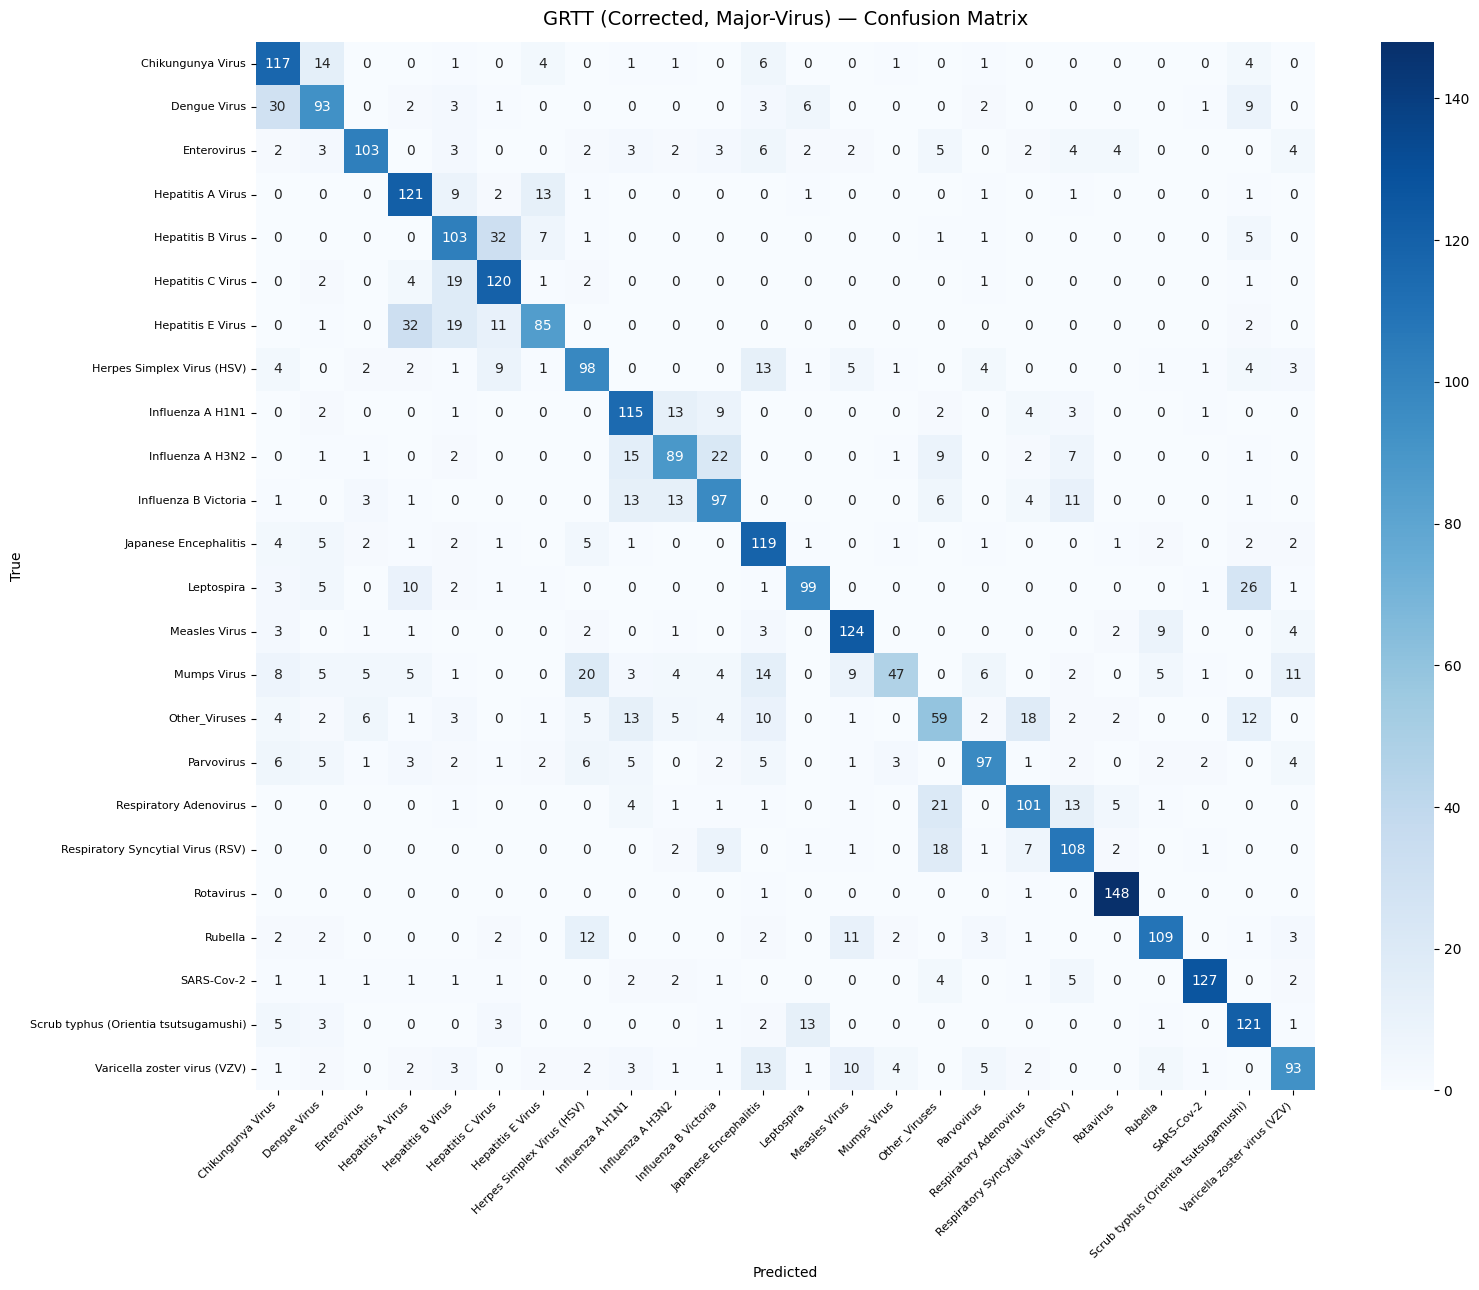

  Confusion matrix saved → grtt_major_corrected_output/confusion_matrix.png


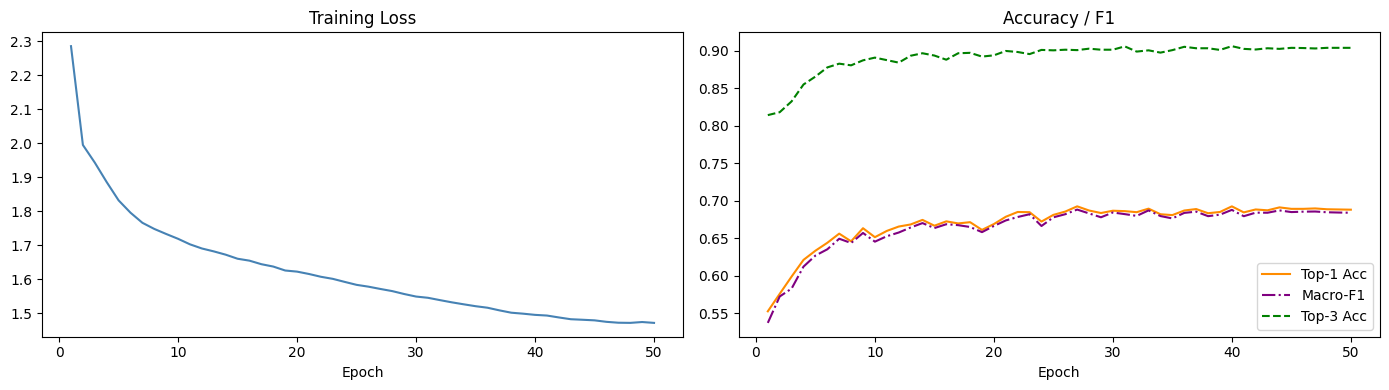

  Training curves saved → grtt_major_corrected_output/training_curves.png

STEP 6 — SHAP FEATURE IMPORTANCE ANALYSIS

SECTION 9 — SHAP FEATURE IMPORTANCE ANALYSIS
  ⚠ shap not installed — skipping SHAP analysis.
    Install with: pip install shap

SECTION 11 — PRODUCTION .PTH EXPORT
  ✓ Loaded best weights from: grtt_major_corrected_output/grtt_major_corrected_best.pt
  ✓ Saved: grtt_major_corrected_output/grtt_major_production.pth  (2.05 MB)

  Verifying bundle (reload + shape check) ...
  ✓ Smoke-test passed — logits shape: (1, 24)  (expected [1, 24])
  ✓ Virus classes: 24
  ✓ Feature cols : binary=40  cont=15  cat=35
  ✓ Best Acc=0.6925  Macro-F1=0.6882  Epoch=27

  ── How to load in Streamlit ──────────────────────────────────
  import torch
  ckpt   = torch.load('grtt_major_production.pth', map_location='cpu')
  model  = GRTT(**ckpt['model_config'])
  model.load_state_dict(ckpt['model_state_dict'])
  model.eval()
  # then use ckpt['scaler'], ckpt['imputer'],
  # ckpt['cat_encoders

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION 10 — MAIN: RUN GRTT (Corrected, Major-Virus)
# ═══════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":

    print("\n" + "="*80)
    print("  GRTT (Corrected) — Major-Virus Dataset")
    print("  d_token=128 | n_heads=4 | batch=128 | label_smooth=0.05")
    print("  λ_contrast=0.10 | weight_decay=1e-4 | sqrt-balanced class weights")
    print("  + Fixed H1N1 downsample name bug")
    print("="*80)

    encoding_df   = pd.read_csv("encoding_major_VIRUS_NAME.csv")
    virus_mapping = dict(zip(encoding_df["Encoded"], encoding_df["Original"]))

    # ── Step 1: Feature engineering ────────────────────────────────────────
    X_train, X_test, y_train, y_test = prepare_data_with_features(
        use_feature_engineering  = True,
        use_symptom_interactions = True,
        use_geo_temporal         = True,
    )

    # ── Step 2: Downsample dominant classes ────────────────────────────────
    X_train, X_test, y_train, y_test, vm_final = filter_and_downsample(
        X_train, X_test, y_train, y_test, virus_mapping,
    )

    # ── Step 3: Build PyTorch data ─────────────────────────────────────────
    data_dict = prepare_pytorch_data(
        X_train, X_test, y_train, y_test,
        class_weight_mode = "sqrt_balanced",
        class_weight_cap  = 10.0,
        batch_size        = 128,
    )

    # ── Step 4: Train (corrected hyperparameters) ──────────────────────────
    result = train_grtt(
        data_dict       = data_dict,
        epochs          = 50,
        d_token         = 128,
        depth           = 2,
        n_heads         = 4,
        dropout         = 0.2,
        token_drop      = 0.05,
        lr              = 1e-3,
        weight_decay    = 1e-4,
        max_lr          = 3e-3,
        label_smoothing = 0.05,
        lambda_contrast = 0.10,
        grad_clip       = 1.0,
        save_dir        = "grtt_major_corrected_output",
    )

    print("\n" + "="*80)
    print("FINAL RESULTS — GRTT (Corrected, Major-Virus)")
    print("="*80)
    print(f"  Best Top-1 Acc : {result['best_acc']:.4f}  (target ≥ 0.7079)")
    print(f"  Best Macro-F1  : {result['best_f1_macro']:.4f}")
    print(f"  Best Epoch     : {result['best_epoch']}")
    print(f"  Parameters     : {result['total_params']:,}")
    print(f"  Training Time  : {result['training_time']:.1f}s")
    print("="*80)

    # ── Step 5: Detailed evaluation ────────────────────────────────────────
    evaluate_model(result["model"], data_dict, vm_final,
                   save_dir="grtt_major_corrected_output")

    # ── Step 6: SHAP (gracefully skipped if shap not installed) ────────────
    print("\n" + "="*80)
    print("STEP 6 — SHAP FEATURE IMPORTANCE ANALYSIS")
    print("="*80)
    importance_df, shap_values, feature_names = compute_shap_importance(
        model       = result["model"],
        X_train     = X_train,
        X_test      = X_test,
        save_dir    = "grtt_major_corrected_output",
        n_background= 200,
        n_explain   = 400,
    )

    # ── Step 7: Export production .pth bundle ──────────────────────────────
    export_production_pth(
        model        = result["model"],
        data_dict    = data_dict,
        vm_final     = vm_final,
        train_result = result,
        save_dir     = "grtt_major_corrected_output",
        d_token      = 128,
        depth        = 2,
        n_heads      = 4,
        dropout      = 0.2,
        token_drop   = 0.05,
    )

